# Comparison between the different altimetric product
- surface + 15m depth
- $\Delta T$<3h
- Gradient compute from the duacs speed


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, compute_variance, extract_mean_geo

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# Generate

In [2]:
dt=3
distance_to_coast_max = 20e3
alti_product_key='swot2km'


In [3]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot250m',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    base_dic, 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etaf'}),
    update_dict(base_dic, {'alti_product_key':'swot2km'}), 
    update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
    update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),
]

l = [
    'L3-250m-xr-etac',
    'L3-250m-xr-etaf',
    'L3-250m-stencil-etac',
    'L3-250m-stencil-etaf',
    'L3-250m-duacsv',
    'L3-2km-xr-etac',
    'L3-2km-xr-etaf',
    'L3-2km-stencil-etac',
    'L3-2km-stencil-etaf',
    'L3-2km-duacsv',
    'L4-no-SWOT-regional-duacsv',
    'L4-no-SWOT-global-duacsv',
    'L4-SWOT-nadir-duacsv']


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = dict(dt='12h', 
            drifter_preprocess = '',
            drifter_preprocess_param='',
            alti_product_key='swot250m',
            alti_diff_method = 'fromduacsv',
            alti_diff_method_param = '',
            ggd_var = 'fromduacsv',
            wd_product_key = 'era5', 
            wd_model ='rio', 
            wd_depth = '15')
comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    base_dic, 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_product_key':'swot2km'}), 
    update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
    update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),
]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

358076
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_xarray_diff__etac__era5_rio0
357404
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_xarray_diff__etaf__era5_rio0
348264
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_diff_only__etac__era5_rio0
343968
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_diff_only__etaf__era5_rio0
349647
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_fromduacsv__fromduacsv__era5_rio0
303001
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_xarray_diff__etac__era5_rio0
300939
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_xarray_diff__etaf__era5_rio0
221705
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etac__era5_rio0
214210
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etaf__era5_rio0
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is avail

In [14]:
def compute_variance(ds_, dirname = ('e', 'n')):
    """ Compute closure stats
    ds : dataset containing terms values for all row_numbers
    dirname : directions of the reconstruction
    """
    
    var = ['acc', 'cor', 'ggd', 'wd']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']

    ds=ds_.copy()
    # remove mean
    for dir_ in dirname : 
        for v in var:
            ds[v+dir_] = ds[v+dir_]-ds[v+dir_].mean('row_number')
            
        # sum 
        ds['sum'+dir_] = sum([ds[v+dir_] for v in var])

        # simple var + sum- one term
        for v in var :
            ds['exc'+dir_+'_'+v] = ds['sum'+dir_]-ds[v+dir_]
                
        #2 by 2 product    
        import itertools
        l = {'acc':'acc'+dir_, 'cor':'cor'+dir_, 'ggd':'ggd'+dir_, 'wd':'wd'+dir_}
        couple = list(itertools.combinations(list(l.keys()),2))
        for c in couple : 
            ds['prod'+dir_+'_'+'_'.join(c)] = ds[c[0]+dir_] * ds[c[1]+dir_]

    # MS = var as mean are null
    dss = compute_mean_square(ds, dirname)
    return dss

In [15]:
DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<1e-4) & (abs(DS.ggdn)<1e-4), drop=True)
DS = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

ds = compute_variance(DS)/U2

# Closure figs
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')


In [7]:
ds.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'alticomp.nc'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [54]:
ds = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'alticomp.nc'))
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')

# Closure figs
print(DSS.sizes['row_number'])
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


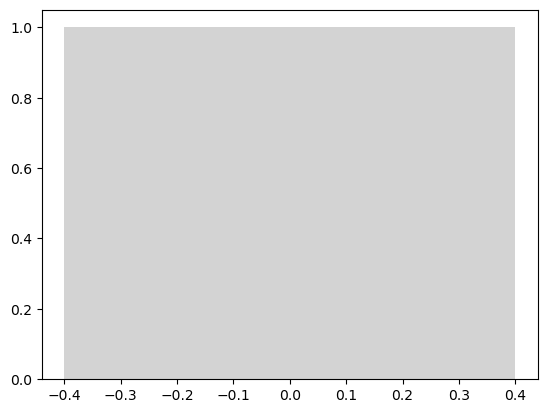

In [16]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


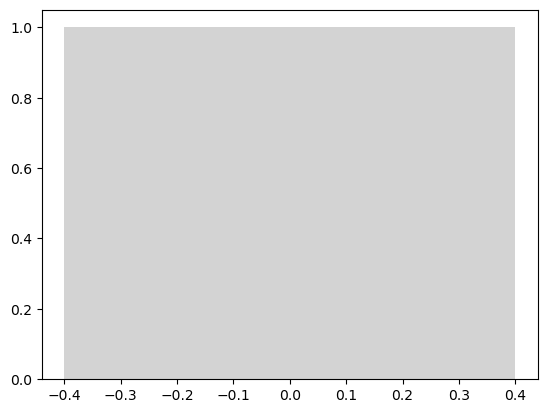

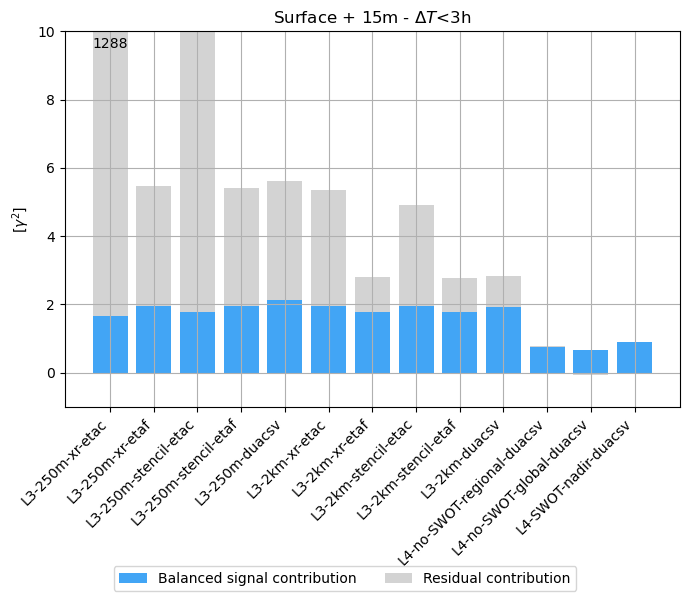

In [21]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45, ha='right' )
ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(-1,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


In [22]:
DS[['accn', 'ggdn', 'corn', 'wdn']].mean('row_number')/DS[['accn', 'ggdn', 'corn', 'wdn']].std('row_number') 

<xarray.Dataset> Size: 2kB
Dimensions:  (id_comb: 13)
Coordinates:
  * id_comb  (id_comb) <U26 1kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadir-duacsv'
Data variables:
    accn     (id_comb) float64 104B -0.07236 -0.07236 ... -0.07236 -0.07236
    ggdn     (id_comb) float64 104B -0.02103 -0.1299 -0.0227 ... -0.4202 -0.3501
    corn     (id_comb) float64 104B 0.1052 0.1052 0.1052 ... 0.1052 0.1052
    wdn      (id_comb) float64 104B 0.2037 0.2037 0.2037 ... 0.2037 0.2037

In [23]:
v=['accn', 'ggdn', 'corn', 'wdn', 'acce', 'ggde', 'core', 'wde']
(DS[v]**2).mean('row_number')/DS[v].var('row_number') 

<xarray.Dataset> Size: 2kB
Dimensions:  (id_comb: 13)
Coordinates:
  * id_comb  (id_comb) <U26 1kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadir-duacsv'
Data variables:
    accn     (id_comb) float64 104B 1.005 1.005 1.005 ... 1.005 1.005 1.005
    ggdn     (id_comb) float64 104B 1.0 1.017 1.001 1.017 ... 1.133 1.177 1.123
    corn     (id_comb) float64 104B 1.011 1.011 1.011 ... 1.011 1.011 1.011
    wdn      (id_comb) float64 104B 1.042 1.042 1.042 ... 1.042 1.042 1.042
    acce     (id_comb) float64 104B 1.003 1.003 1.003 ... 1.003 1.003 1.003
    ggde     (id_comb) float64 104B 1.0 1.02 1.0 1.02 ... 1.162 1.146 1.127
    core     (id_comb) float64 104B 1.074 1.074 1.074 ... 1.074 1.074 1.074
    wde      (id_comb) float64 104B 1.109 1.109 1.109 ... 1.109 1.109 1.109

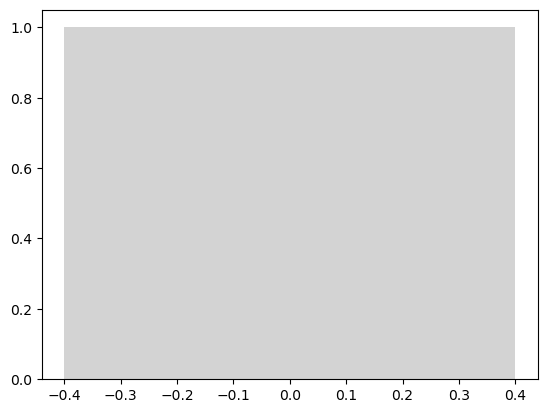

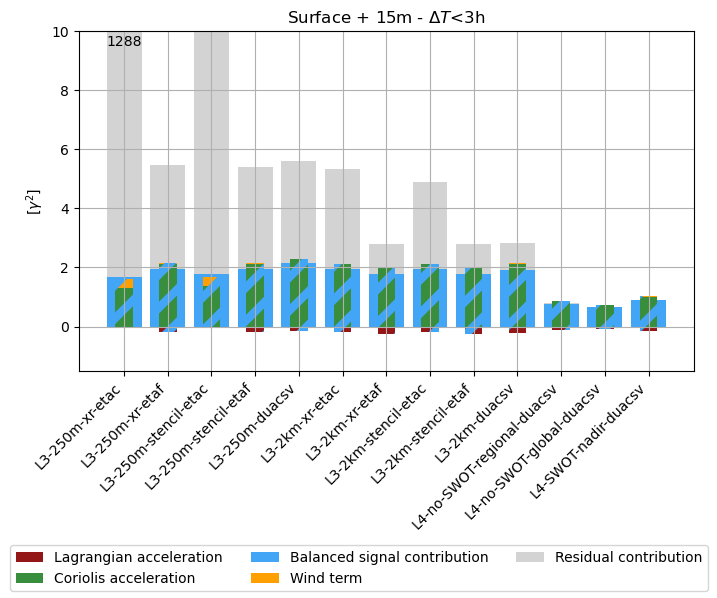

In [24]:
fig, ax=plt.subplots()
ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45,ha='right' )
ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(-1.5,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


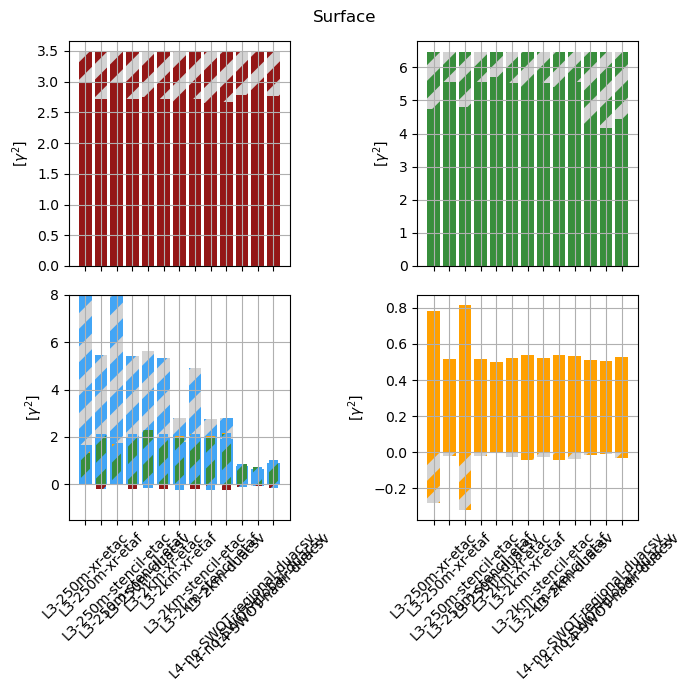

In [25]:
# Alti comparison
vars = ['acc', 'cor', 'ggd','wd']
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(2, 2, figsize = (7, 7), frameon=False, sharex=True)
axs = axs.flatten()
for i in range(len(df)):
    df_ = df.iloc[i]
    plt.rcParams["hatch.linewidth"] = 8
    for j in range(4):
        ax=axs[j]
        # residual contribution
        plt.rcParams["hatch.color"] = "lightgrey"
        if df_['E_'+vars[j]]>0: ax.bar(i, df_['E_'+vars[j]], bottom = df_['B_'+vars[j]],color = c0[vars[j]], hatch="/")
        else: ax.bar(i, df_['E_'+vars[j]], color = c0[vars[j]], hatch="/")
        ax.bar(i, df_['B_'+vars[j]],color = c0[vars[j]])


    ax = axs[2]
    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)

for ax in axs :    
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )

axs[2].set_ylim(-1.5,8)
fig.suptitle('Surface')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_all.png'))


# For papers


In [26]:
df0 = df.copy()

In [27]:
df0 = df0.loc[[
       'L3-250m-stencil-etac', 'L3-250m-stencil-etaf',
    'L3-2km-stencil-etac', 'L3-2km-stencil-etaf', 'L4-SWOT-nadir-duacsv', 'L4-no-SWOT-regional-duacsv',
       'L4-no-SWOT-global-duacsv']]
df0 = df0.reset_index()
df0['Altimetric product'] = ['Calibrated L3-250m', 
                             'Filtered L3-250m',
                             'Calibrated L3-2km', 
                             'Filtered L3-2km', 
                             'L4-SWOT-nadir',
                             'L4-regional',
                             'L4-global', 
                            ]


In [28]:
df0 = df0.set_index('Altimetric product')
#df0 = df.reindex(['Filtered L3-250m', 'Calibrated L3-2km', 'Filtered L3-2km','L4-SWOT-nadir', 'L4-regional', 'L4-global',])

In [29]:
df0.E_ggd

Altimetric product
Calibrated L3-250m    945.948113
Filtered L3-250m        3.439947
Calibrated L3-2km       2.964094
Filtered L3-2km         1.006525
L4-SWOT-nadir           0.006130
L4-regional             0.018368
L4-global              -0.053767
Name: E_ggd, dtype: float64

In [30]:
df0.B_ggd

Altimetric product
Calibrated L3-250m    1.764685
Filtered L3-250m      1.961401
Calibrated L3-2km     1.945713
Filtered L3-2km       1.771842
L4-SWOT-nadir         0.889682
L4-regional           0.764885
L4-global             0.651495
Name: B_ggd, dtype: float64

In [31]:
df0.E_ggd/df0.GGD

Altimetric product
Calibrated L3-250m    0.998138
Filtered L3-250m      0.636868
Calibrated L3-2km     0.603709
Filtered L3-2km       0.362272
L4-SWOT-nadir         0.006843
L4-regional           0.023451
L4-global            -0.089953
dtype: float64

In [32]:
df0.B_ggd/df0.B_ggd.loc['Filtered L3-2km']

Altimetric product
Calibrated L3-250m    0.995961
Filtered L3-250m      1.106984
Calibrated L3-2km     1.098130
Filtered L3-2km       1.000000
L4-SWOT-nadir         0.502122
L4-regional           0.431689
L4-global             0.367694
Name: B_ggd, dtype: float64

In [33]:
from diagnosis import sshnoisestd_from_MSnoiseggd
sshnoisestd_from_MSnoiseggd(df0.E_ggd)*1e2

Caution : E_ggd must be given in gamma^2, std must return in m


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Altimetric product
Calibrated L3-250m    8.196621
Filtered L3-250m      0.494285
Calibrated L3-2km     0.458825
Filtered L3-2km       0.267370
L4-SWOT-nadir         0.020866
L4-regional           0.036119
L4-global                  NaN
Name: E_ggd, dtype: float64

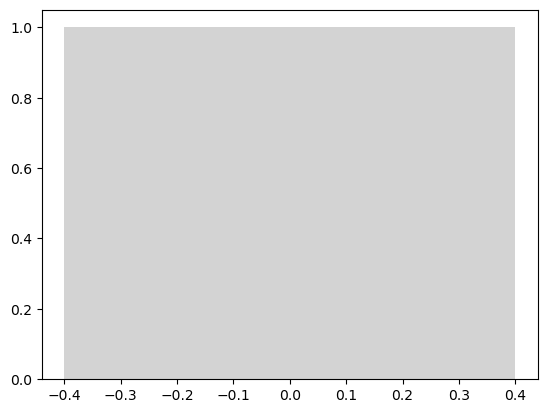

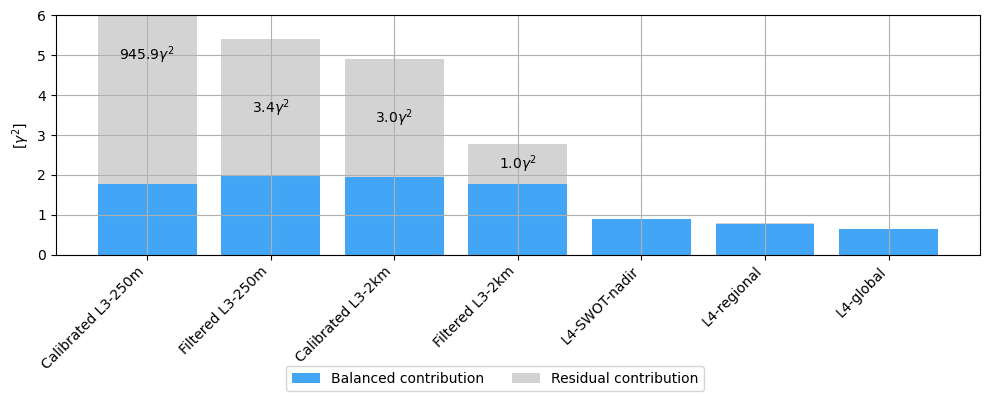

In [34]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(10,4))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df0)):
    df_ = df0.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])
    if i==0 :
        ax.text(
            i,
            5,
            str(np.round(df_["E_ggd"], 1))+r'$\gamma^2$',
            horizontalalignment="center",
            verticalalignment="center",
        )
    if i in [1, 2, 3]:
        ax.text(
            i,
            df_["B_ggd"]+ df_["E_ggd"]/2,
            str(np.round(df_["E_ggd"], 1))+r'$\gamma^2$',
            horizontalalignment="center",
            verticalalignment="center",
        )

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df0)),labels = df0.index, rotation = 45, ha='right' )
#ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0,6)
#ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


In [35]:
df.E_ggd/df.GGD*100

Altimetric product
L3-250m-xr-etac               99.870544
L3-250m-xr-etaf               64.125289
L3-250m-stencil-etac          99.813795
L3-250m-stencil-etaf          63.686820
L3-250m-duacsv                61.928596
L3-2km-xr-etac                63.370748
L3-2km-xr-etaf                36.773391
L3-2km-stencil-etac           60.370889
L3-2km-stencil-etaf           36.227207
L3-2km-duacsv                 31.548226
L4-no-SWOT-regional-duacsv     2.345118
L4-no-SWOT-global-duacsv      -8.995261
L4-SWOT-nadir-duacsv           0.684310
dtype: float64

# Related SSH RMS 

In [36]:
A = 141464.15110761
def sigmassh(E_ggd) : return np.sqrt(E_ggd/A)

#
sigmassh(df.E_ggd)/1e-2 # cm

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Altimetric product
L3-250m-xr-etac               9.535583
L3-250m-xr-etaf               0.497629
L3-250m-stencil-etac          8.177310
L3-250m-stencil-etaf          0.493120
L3-250m-duacsv                0.495927
L3-2km-xr-etac                0.489285
L3-2km-xr-etaf                0.270261
L3-2km-stencil-etac           0.457744
L3-2km-stencil-etaf           0.266741
L3-2km-duacsv                 0.250760
L4-no-SWOT-regional-duacsv    0.036034
L4-no-SWOT-global-duacsv           NaN
L4-SWOT-nadir-duacsv          0.020817
Name: E_ggd, dtype: float64

In [37]:
# Variance
sigmassh(df.E_ggd)**2/1e-4 # cm^2

Altimetric product
L3-250m-xr-etac               90.927351
L3-250m-xr-etaf                0.247635
L3-250m-stencil-etac          66.868398
L3-250m-stencil-etaf           0.243167
L3-250m-duacsv                 0.245943
L3-2km-xr-etac                 0.239400
L3-2km-xr-etaf                 0.073041
L3-2km-stencil-etac            0.209530
L3-2km-stencil-etaf            0.071151
L3-2km-duacsv                  0.062881
L4-no-SWOT-regional-duacsv     0.001298
L4-no-SWOT-global-duacsv            NaN
L4-SWOT-nadir-duacsv           0.000433
Name: E_ggd, dtype: float64

# Differenciation methods comparisons

In [38]:
df1 = df.copy()
df1 = df1.loc[['L3-250m-duacsv', 'L3-250m-stencil-etaf', 'L3-250m-xr-etaf']]
df1 = df1.reset_index()
df1['Altimetric product'] = ['From duacs velocities', 'Stencil differentiation','Centered differentiation',]
df1 = df1.set_index('Altimetric product')

df2 = df.copy()
df2 = df2.loc[['L3-2km-duacsv', 'L3-2km-stencil-etaf', 'L3-2km-xr-etaf']]
df2 = df2.reset_index()
df2['Altimetric product'] = ['From duacs velocities', 'Stencil differentiation','Centered differentiation',]
df2 = df2.set_index('Altimetric product')

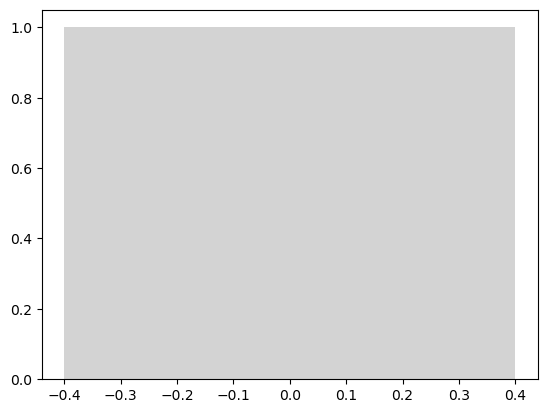

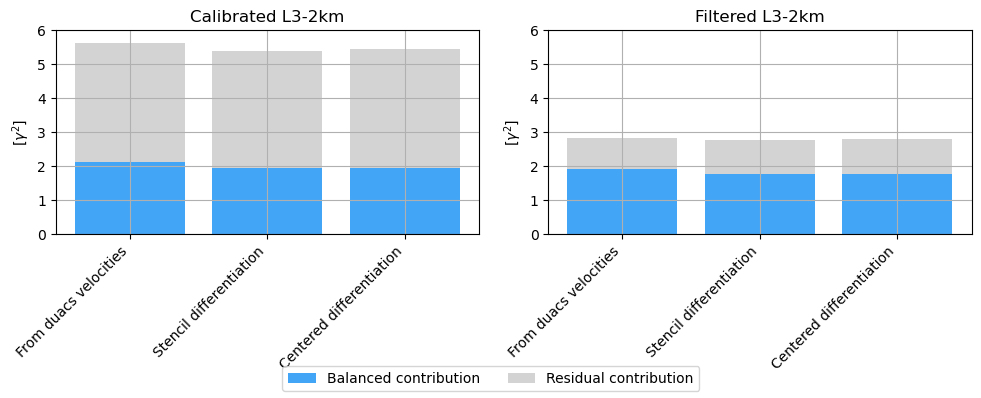

In [39]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, axs = plt.subplots(1,2, frameon=False, figsize=(10,4))
plt.rcParams["axes.edgecolor"] = "k"

ax = axs[0]
for i in range(len(df1)):
    df_ = df1.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df1)),labels = df1.index, rotation = 45, ha='right' )
#ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0,6)
ax.set_title('Calibrated L3-2km')

ax = axs[1]
for i in range(len(df2)):
    df_ = df2.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df2)),labels = df2.index, rotation = 45, ha='right' )
#ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0,6)
ax.set_title('Filtered L3-2km')


#ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


In [ ]:
df1